<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Fall_2025/blob/main/Module%206/28_LIME_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1) LIME — Iris (tabular) + Images


# Explainable NN: LIME

In [1]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=28e89ea162bed78a91d54f234a5f9c17e51b7bdc8daff6161ff572f853363709
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


## LIME for Iris

In [2]:
import lime
import lime.lime_tabular
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load Iris dataset
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=42)

# Train a Random Forest Classifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# Initialize a LIME Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(X_train, feature_names=iris.feature_names, class_names=iris.target_names, discretize_continuous=True)

# Choose an instance to explain
idx = 20  # Change this to explain different test instances
instance = X_test[idx]

# Generate explanation for the chosen instance
exp = explainer.explain_instance(instance, rf.predict_proba, num_features=4, top_labels=1)

# Show the explanation
exp.show_in_notebook(show_table=True, show_all=False)
# Or use exp.as_pyplot_figure() if not using Jupyter Notebook

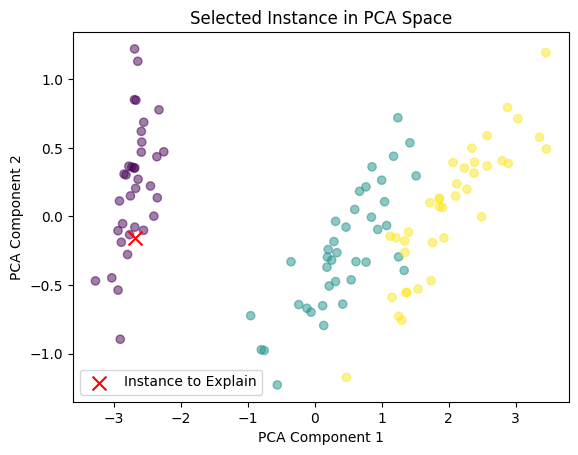

In [3]:
from sklearn.decomposition import PCA

# PCA to reduce dimensions for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Plotting the selected instance
instance_pca = pca.transform(instance.reshape(1, -1))

# Highlight the selected instance
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.5)
plt.scatter(instance_pca[:, 0], instance_pca[:, 1], color='red', marker='x', s=100, label='Instance to Explain')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.title('Selected Instance in PCA Space')
plt.show()


##LIME for Cat (or CIFAR)

In [4]:
!gdown https://drive.google.com/uc?id=1e9qvvitE0e5FRz1kGpR-4k8vRv6i9Zbp

import tensorflow as tf
cat_image = tf.io.read_file('/content/cute.jpg')
cat_image = tf.image.decode_jpeg(cat_image)
cat_image = tf.image.resize(cat_image, (299, 299))  # Resize to match InceptionV3 input size

Downloading...
From: https://drive.google.com/uc?id=1e9qvvitE0e5FRz1kGpR-4k8vRv6i9Zbp
To: /content/cute.jpg
100% 140k/140k [00:00<00:00, 39.5MB/s]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import vgg16
from tensorflow.keras.datasets import cifar10

from lime import lime_image
from skimage.segmentation import mark_boundaries
from skimage.transform import resize

# Load VGG16 model pre-trained on ImageNet
model = vgg16.VGG16(weights='imagenet', include_top=True)

# Load CIFAR-10 data
(_, _), (x_test, y_test) = cifar10.load_data()

# Select an image from CIFAR-10
image = x_test[9]
image = np.array(cat_image) #comment this line out to explore for CIFAR-10

# Resize the image to 224x224 for VGG16
image_resized = resize(image, (224, 224), preserve_range=True)

# Preprocess the image for VGG16 model
image_preprocessed = vgg16.preprocess_input(image_resized.copy())

# Predict the image using VGG16
preds = model.predict(np.array([image_preprocessed]))
predicted_class = vgg16.decode_predictions(preds, top=1)[0][0][1]
print(f"Predicted: {predicted_class}")

# Initialize LIME for image explanation
explainer = lime_image.LimeImageExplainer()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 845ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted: kit_fox


In [6]:
# Explain the prediction
explanation = explainer.explain_instance(image_resized.astype(np.float32),
                                         model.predict,
                                         top_labels=5,
                                         hide_color=0,
                                         num_samples=1000)

# Display the explanation for the top class
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=False,
                                            num_features=10,
                                            hide_rest=True)

# plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
# plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 

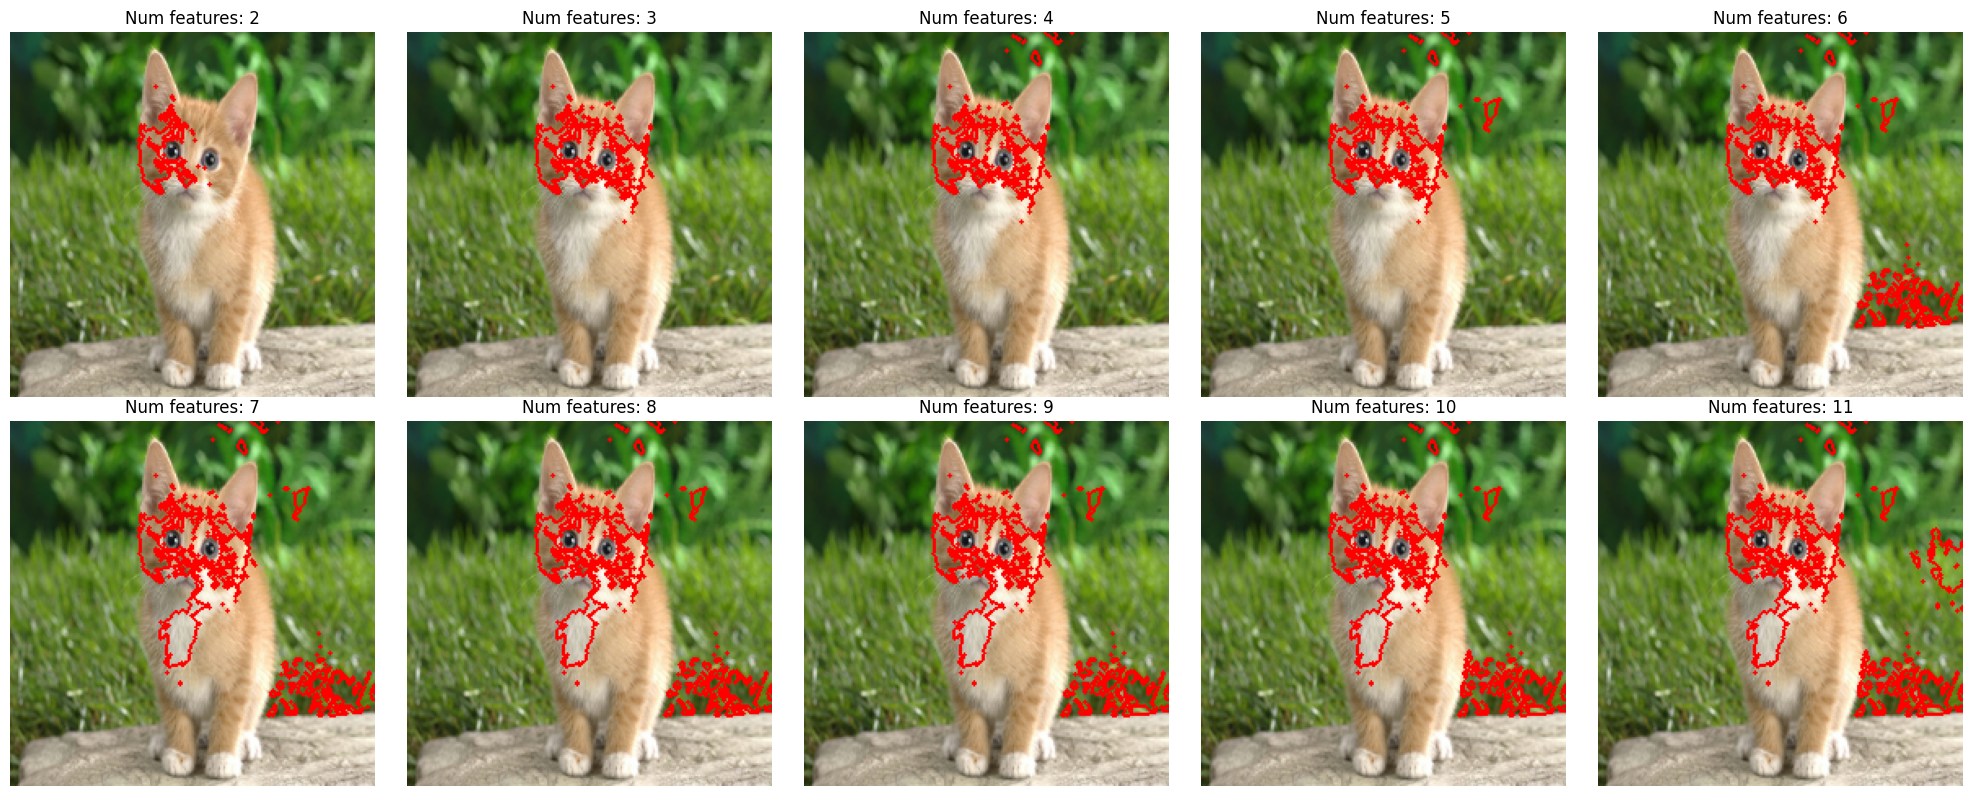

In [7]:
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

# Assuming 'explanation' is already obtained from LIME as before

# Create a figure with 5 columns and 2 rows
fig, axs = plt.subplots(2, 5, figsize=(20, 8))

for i, num_features in enumerate(range(2, 12)):
    # Get the mask for the superpixels
    _, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=num_features, hide_rest=False)

    # Find the row and column to place this subplot
    row = i // 5
    col = i % 5

    # Superimpose the mask on the original image
    img_boundaries = mark_boundaries(image_resized / 255.0, mask, color=(1,0,0), mode='thick')

    # Plotting
    axs[row, col].imshow(img_boundaries)
    axs[row, col].set_title(f'Num features: {num_features}')
    axs[row, col].axis('off')

plt.tight_layout()
plt.show()
